In [1]:
import bw2data, bw2io, bw2calc
import numpy as np
import os
import re
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt

In [2]:
df_full = pd.read_excel("plot_rankshift_hydro_v2_reservoir.xlsx")
#df_full_sorted.head()

# remove the index column if present
if "Unnamed: 0" in df_full.columns:
    df_full = df_full.drop(columns=["Unnamed: 0"])


## plot 

### barplot function: to show real magnitude : 

- we put normalized 2050 scores (lower than the 2030) as basebar,
- then put the normalized 2030 scores on top as a stacked bar

### then normalization choice determines whether wind’s 2030 bar disappears (or becomes visually misleading) 
- now we normalize 2030 and 2050 separately, but then wind (2030 vs. 2050 diff) disappears


#### function - dual normalization choice 

In [3]:
# corrected legend 
def lighten(color, amount=0.45):
    import matplotlib.colors as mc, colorsys
    try:
        c = mc.cnames[color]
    except KeyError:
        c = color
    r, g, b = mc.to_rgb(c)
    h, l, s = colorsys.rgb_to_hls(r, g, b)
    l_new = 1 - amount * (1 - l)
    return colorsys.hls_to_rgb(h, l_new, s)


def plot_stacked_normalized_bars(
    df_full,
    metric_order,
    metric_labels,
    countries=("CN", "US"),
    ssps=("SSP1-VLLO", "SSP2-M", "SSP5-H"),
    technologies=("Hydro", "Wind", "PV"),
    tech_colors=None,
    bar_width=0.23,
    norm_choice="both_years",  # "per_year" or "both_years"
):
    """
    norm_choice:
      - "per_year":
            n2030 = s2030 / max(score_2030 over techs, same metric)
            n2050 = s2050 / max(score_2050 over techs, same metric)
      - "both_years":
            pivot = max(score_2030, score_2050 over techs, same metric)
            n2030 = s2030 / pivot
            n2050 = s2050 / pivot
    """

    if tech_colors is None:
        tech_colors = {"Hydro": "#7B7B7B", "Wind": "#006BA4", "PV": "#FF800E"}

    fig, axes = plt.subplots(
        nrows=len(ssps),
        ncols=len(countries),
        figsize=(18, 15),
        sharey=True,
    )
    plt.subplots_adjust(hspace=0.35, wspace=0.22)

    YPAD = 2  # annotation spacing

    for i, ssp in enumerate(ssps):
        for j, country in enumerate(countries):
            ax = axes[i, j]

            sub = df_full[(df_full["SSP"] == ssp) & (df_full["Country"] == country)]
            x_positions = np.arange(len(metric_order))
            offset = np.linspace(-bar_width, bar_width, len(technologies))

            # -----------------------------------------------------
            # Shading for dpLCI metrics
            # -----------------------------------------------------
            for k, metric in enumerate(metric_order):
                if metric in [
                    "dyn-FG-LCI + pGWP-fixedCO2",
                    "full dpLCI + pGWP-fixedCO2",
                ]:
                    ax.axvspan(k - 0.5, k + 0.5, color="#CCCCCC", alpha=0.15, zorder=0)

            # -----------------------------------------------------
            # Draw bars for each technology
            # -----------------------------------------------------
            for t_index, tech in enumerate(technologies):
                t_df = sub[sub["Technology"] == tech]

                norm2030, norm2050 = [], []
                raw2030, raw2050 = [], []

                # Collect normalized and raw values
                for metric in metric_order:
                    sc2030 = t_df[(t_df["Metric"] == metric) & (t_df["Year"] == 2030)]["Score"]
                    sc2050 = t_df[(t_df["Metric"] == metric) & (t_df["Year"] == 2050)]["Score"]

                    s2030 = sc2030.values[0] if len(sc2030) else np.nan
                    s2050 = sc2050.values[0] if len(sc2050) else np.nan

                    raw2030.append(s2030 * 1000 if not np.isnan(s2030) else np.nan)
                    raw2050.append(s2050 * 1000 if not np.isnan(s2050) else np.nan)

                    # ---------- NORMALIZATION ----------
                    if norm_choice == "per_year":
                        max2030 = sub[(sub["Metric"] == metric) & (sub["Year"] == 2030)]["Score"].max()
                        max2050 = sub[(sub["Metric"] == metric) & (sub["Year"] == 2050)]["Score"].max()

                        n2030 = (s2030 / max2030 * 100) if max2030 else np.nan
                        n2050 = (s2050 / max2050 * 100) if max2050 else np.nan

                    elif norm_choice == "both_years":
                        pivot = sub[sub["Metric"] == metric]["Score"].max()
                        if pivot and not np.isnan(pivot):
                            n2030 = (s2030 / pivot * 100) if not np.isnan(s2030) else np.nan
                            n2050 = (s2050 / pivot * 100) if not np.isnan(s2050) else np.nan
                        else:
                            n2030 = n2050 = np.nan
                    else:
                        raise ValueError("norm_choice must be 'per_year' or 'both_years'")

                    norm2030.append(n2030)
                    norm2050.append(n2050)

                norm2030 = np.array(norm2030, dtype=float)
                norm2050 = np.array(norm2050, dtype=float)
                top_seg = norm2030 - norm2050

                xpos = x_positions + offset[t_index]

                # -----------------------------------------------------
                # LEGEND LABELS — each tech×year once (first subplot)
                # -----------------------------------------------------
                if i == 0 and j == 0:
                    label2050 = f"{tech} 2050"
                    label2030 = f"{tech} 2030"
                else:
                    label2050 = None
                    label2030 = None

                # 2050 base bar
                ax.bar(
                    xpos,
                    norm2050,
                    width=bar_width,
                    color=tech_colors[tech],
                    edgecolor="black",
                    label=label2050,
                )

                # 2030 top segment
                ax.bar(
                    xpos,
                    top_seg,
                    bottom=norm2050,
                    width=bar_width,
                    color=lighten(tech_colors[tech], 0.40),
                    edgecolor="black",
                    label=label2030,
                )

                # ------------------------------
                # Annotation placement rules
                # ------------------------------
                for xi, base, top, r2030, r2050 in zip(
                    xpos, norm2050, top_seg, raw2030, raw2050
                ):

                    if tech == "Hydro":
                        # Hydro special: 2050 at bottom, white text
                        if not np.isnan(r2050):
                            ax.text(
                                xi, 2.0, f"{r2050:.1f}",
                                ha="center", va="bottom",
                                fontsize=11, color="white",
                            )
                        if not np.isnan(r2030):
                            ax.text(
                                xi, base + top + YPAD, f"{r2030:.1f}",
                                ha="center", va="bottom",
                                fontsize=11, color="black",
                            )

                    else:
                        # Wind & PV 2050
                        if not np.isnan(r2050):
                            if base > 30:
                                ax.text(
                                    xi, base * 0.55, f"{r2050:.1f}",
                                    ha="center", va="center",
                                    fontsize=11, color="white",
                                )
                            else:
                                ax.text(
                                    xi, base + 1.0, f"{r2050:.1f}",
                                    ha="center", va="bottom",
                                    fontsize=11, color="black",
                                )

                        # Wind & PV 2030
                        if not np.isnan(r2030):
                            ax.text(
                                xi, base + top + YPAD, f"{r2030:.1f}",
                                ha="center", va="bottom",
                                fontsize=11, color="black",
                            )

            # ------------------------------
            # Layout per subplot
            # ------------------------------
            ax.set_title(f"{country}, {ssp}", fontsize=14, pad=8)
            ax.grid(axis="y", linestyle=":", alpha=0.35)
            ax.set_ylim(0, 125)

            if i == len(ssps) - 1:
                ax.set_xticks(x_positions)
                ax.set_xticklabels(
                    [metric_labels[m] for m in metric_order],
                    rotation=28, ha="right",
                )
            else:
                ax.set_xticks([])

    # Legend: now includes Hydro/Wind/PV, 2030 & 2050
    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        title="Technology / Year",
        loc="lower center",
        bbox_to_anchor=(0.5, -0.02),
        ncol=6,
        fontsize=12,
        frameon=True,
    )

    fig.suptitle(
        "Normalized stacked bars (0–100) by metric and technology\n"
        f"norm_choice = '{norm_choice}' — 2030 (light) stacked on 2050 (dark); raw GWP×1000 on bars",
        fontsize=17,
        y=0.95,
    )

    return fig, axes


#### bars changed to dots 

In [9]:
SSP_LABEL_MAP = {
    "SSP1-VLLO": "SSP1-19",
    "SSP2-M":    "SSP2-45",
    "SSP5-H":    "SSP5-85",
}

def format_ssp(ssp: str) -> str:
    """Return standardized display name for SSP."""
    return SSP_LABEL_MAP.get(ssp, ssp)




def plot_normalized_dots_replace_bars(
    df_full,
    metric_order,
    metric_labels,
    countries=("CN", "US"),
    ssps=("SSP1-VLLO", "SSP2-M", "SSP5-H"),
    technologies=("Hydro", "Wind", "PV"),
    tech_colors=None,
    norm_choice="both_years",  # "per_year" or "both_years"
    figsize=(18, 15),
):
    """
    DOT-based normalized comparison:
      - Technology → color
      - Year → marker orientation:
            2030 = upward triangle '^'
            2050 = downward triangle 'v'
      - Annotations:
            2030 label ABOVE the marker tip
            2050 label BELOW the marker tip
      - Automatic collision avoidance for labels
    """

    import numpy as np
    import matplotlib.pyplot as plt

    if tech_colors is None:
        tech_colors = {"Hydro": "#7B7B7B", "Wind": "#006BA4", "PV": "#FF800E"}

    # REQUIRED (fixed): 2030 up-triangle, 2050 down-triangle
    year_marker = {2030: "^", 2050: "v"}

    fig, axes = plt.subplots(
        nrows=len(ssps),
        ncols=len(countries),
        figsize=figsize,
        sharey=True,
    )
    plt.subplots_adjust(hspace=0.35, wspace=0.22)

    # -------------------------------------------------
    # Helper: non-overlapping vertical text placement
    # -------------------------------------------------
    """
    def place_text(ax, x, y, text, direction="up", step=2.4, max_tries=50):
       
        #direction = "up" or "down"
        #Ensures new label does not overlap existing ones in the same axes.
        
        fig.canvas.draw()
        renderer = fig.canvas.get_renderer()

        dy = step if direction == "up" else -step

        for _ in range(max_tries):
            txt = ax.text(
                x, y,
                text,
                ha="center",
                va="bottom" if direction == "up" else "top",
                fontsize=10,
                zorder=10,
            )
            fig.canvas.draw()
            bbox = txt.get_window_extent(renderer)

            overlaps = False
            for other in ax.texts[:-1]:
                if bbox.overlaps(other.get_window_extent(renderer)):
                    overlaps = True
                    break

            if not overlaps:
                return txt

            txt.remove()
            y += dy

        # fallback
        return ax.text(
            x, y,
            text,
            ha="center",
            va="bottom" if direction == "up" else "top",
            fontsize=10,
            zorder=10,
        )
    """ 
    
    def place_text(ax, x, y, text, direction="up", step=2.4, max_tries=50, color="black"):
        """
        direction = "up" or "down"
        Ensures new label does not overlap existing ones in the same axes.
        ADD a color option 
        """
        fig.canvas.draw()
        renderer = fig.canvas.get_renderer()
    
        dy = step if direction == "up" else -step
    
        for _ in range(max_tries):
            txt = ax.text(
                x, y,
                text,
                ha="center",
                va="bottom" if direction == "up" else "top",
                fontsize=10,
                color=color,          # <<< NEW
                zorder=10,
            )
            fig.canvas.draw()
            bbox = txt.get_window_extent(renderer)
    
            overlaps = False
            for other in ax.texts[:-1]:
                if bbox.overlaps(other.get_window_extent(renderer)):
                    overlaps = True
                    break
    
            if not overlaps:
                return txt
    
            txt.remove()
            y += dy
        # fallback
        return ax.text(
            x, y,
            text,
            ha="center",
            va="bottom" if direction == "up" else "top",
            fontsize=10,
            color=color,              # <<< NEW
            zorder=10,
        )

    
    # -------------------------------------------------
    # Plotting
    # -------------------------------------------------
    for i, ssp in enumerate(ssps):
        for j, country in enumerate(countries):
            ax = axes[i, j]

            sub = df_full[
                (df_full["SSP"] == ssp) &
                (df_full["Country"] == country)
            ]

            x_positions = np.arange(len(metric_order))
            offsets = np.linspace(-0.18, 0.18, len(technologies))

            # dpLCI shading
            for k, metric in enumerate(metric_order):
                if metric in [
                    "dyn-FG-LCI + pGWP-fixedCO2",
                    "full dpLCI + pGWP-fixedCO2",
                ]:
                    ax.axvspan(k - 0.5, k + 0.5, color="#CCCCCC", alpha=0.15, zorder=0)

            for t_idx, tech in enumerate(technologies):
                t_df = sub[sub["Technology"] == tech]
                xpos = x_positions + offsets[t_idx]

                norm = {2030: [], 2050: []}
                raw  = {2030: [], 2050: []}

                for metric in metric_order:
                    # raw values (Score * 1000) for annotation
                    for year in (2030, 2050):
                        s = t_df[
                            (t_df["Metric"] == metric) &
                            (t_df["Year"] == year)
                        ]["Score"]
                        sval = s.values[0] if len(s) else np.nan
                        raw[year].append(sval * 1000 if not np.isnan(sval) else np.nan)

                    # normalization
                    if norm_choice == "per_year":
                        max2030 = sub[(sub["Metric"] == metric) & (sub["Year"] == 2030)]["Score"].max()
                        max2050 = sub[(sub["Metric"] == metric) & (sub["Year"] == 2050)]["Score"].max()

                        s2030 = t_df[(t_df["Metric"] == metric) & (t_df["Year"] == 2030)]["Score"]
                        s2050 = t_df[(t_df["Metric"] == metric) & (t_df["Year"] == 2050)]["Score"]

                        n2030 = (s2030.values[0] / max2030 * 100) if len(s2030) and max2030 else np.nan
                        n2050 = (s2050.values[0] / max2050 * 100) if len(s2050) and max2050 else np.nan

                    elif norm_choice == "both_years":
                        pivot = sub[sub["Metric"] == metric]["Score"].max()
                        if pivot and not np.isnan(pivot):
                            s2030 = t_df[(t_df["Metric"] == metric) & (t_df["Year"] == 2030)]["Score"]
                            s2050 = t_df[(t_df["Metric"] == metric) & (t_df["Year"] == 2050)]["Score"]
                            n2030 = (s2030.values[0] / pivot * 100) if len(s2030) else np.nan
                            n2050 = (s2050.values[0] / pivot * 100) if len(s2050) else np.nan
                        else:
                            n2030 = n2050 = np.nan
                    else:
                        raise ValueError("norm_choice must be 'per_year' or 'both_years'")

                    norm[2030].append(n2030)
                    norm[2050].append(n2050)

                # plot & annotate
                for year in (2030, 2050):
                    label = f"{tech} {year}" if (i == 0 and j == 0) else None

                    ax.scatter(
                        xpos,
                        norm[year],
                        s=120,
                        marker=year_marker[year],     # <<< FIXED DIRECTION
                        facecolors=tech_colors[tech],
                        edgecolors=tech_colors[tech],
                        linewidths=1.2,
                        zorder=5,
                        label=label,
                    )

                    for xi, yi, ri in zip(xpos, norm[year], raw[year]):
                        if np.isnan(ri) or np.isnan(yi):
                            continue

                        if year == 2030:
                            # REQUIRED: 2030 ABOVE the marker tip
                            place_text(ax, xi, yi + 2.6, f"{ri:.1f}", direction="up", color=tech_colors[tech])
                             
                        else:
                            # REQUIRED: 2050 BELOW the marker tip
                            place_text(ax, xi, yi - 2.6, f"{ri:.1f}", direction="down", color=tech_colors[tech])

            ax.set_title(f"{country}, {format_ssp(ssp)}", fontsize=13)
            ax.grid(axis="y", linestyle=":", alpha=0.35)
            ax.set_ylim(0, 125)

            if i == len(ssps) - 1:
                ax.set_xticks(x_positions)
                ax.set_xticklabels(
                    [metric_labels[m] for m in metric_order],
                    rotation=28,
                    ha="right",
                )
            else:
                ax.set_xticks([])

    # legend
    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        title="Technology / Year",
        loc="lower center",
        bbox_to_anchor=(0.5, -0.02),
        ncol=6,
        fontsize=12,
        frameon=True,
    )

    fig.suptitle(
        "Normalized comparison \n2030 ▲ label above; 2050 ▼ label below",
        fontsize=17,
        y=0.95,
    )

    return fig, axes


## plot 

#####  because it's uniform distribution on the FG dyn LCI, 
##### so without full dpLCI (mapping to the right background), it the same score on dyn-FG-LCI vs. static LCI 

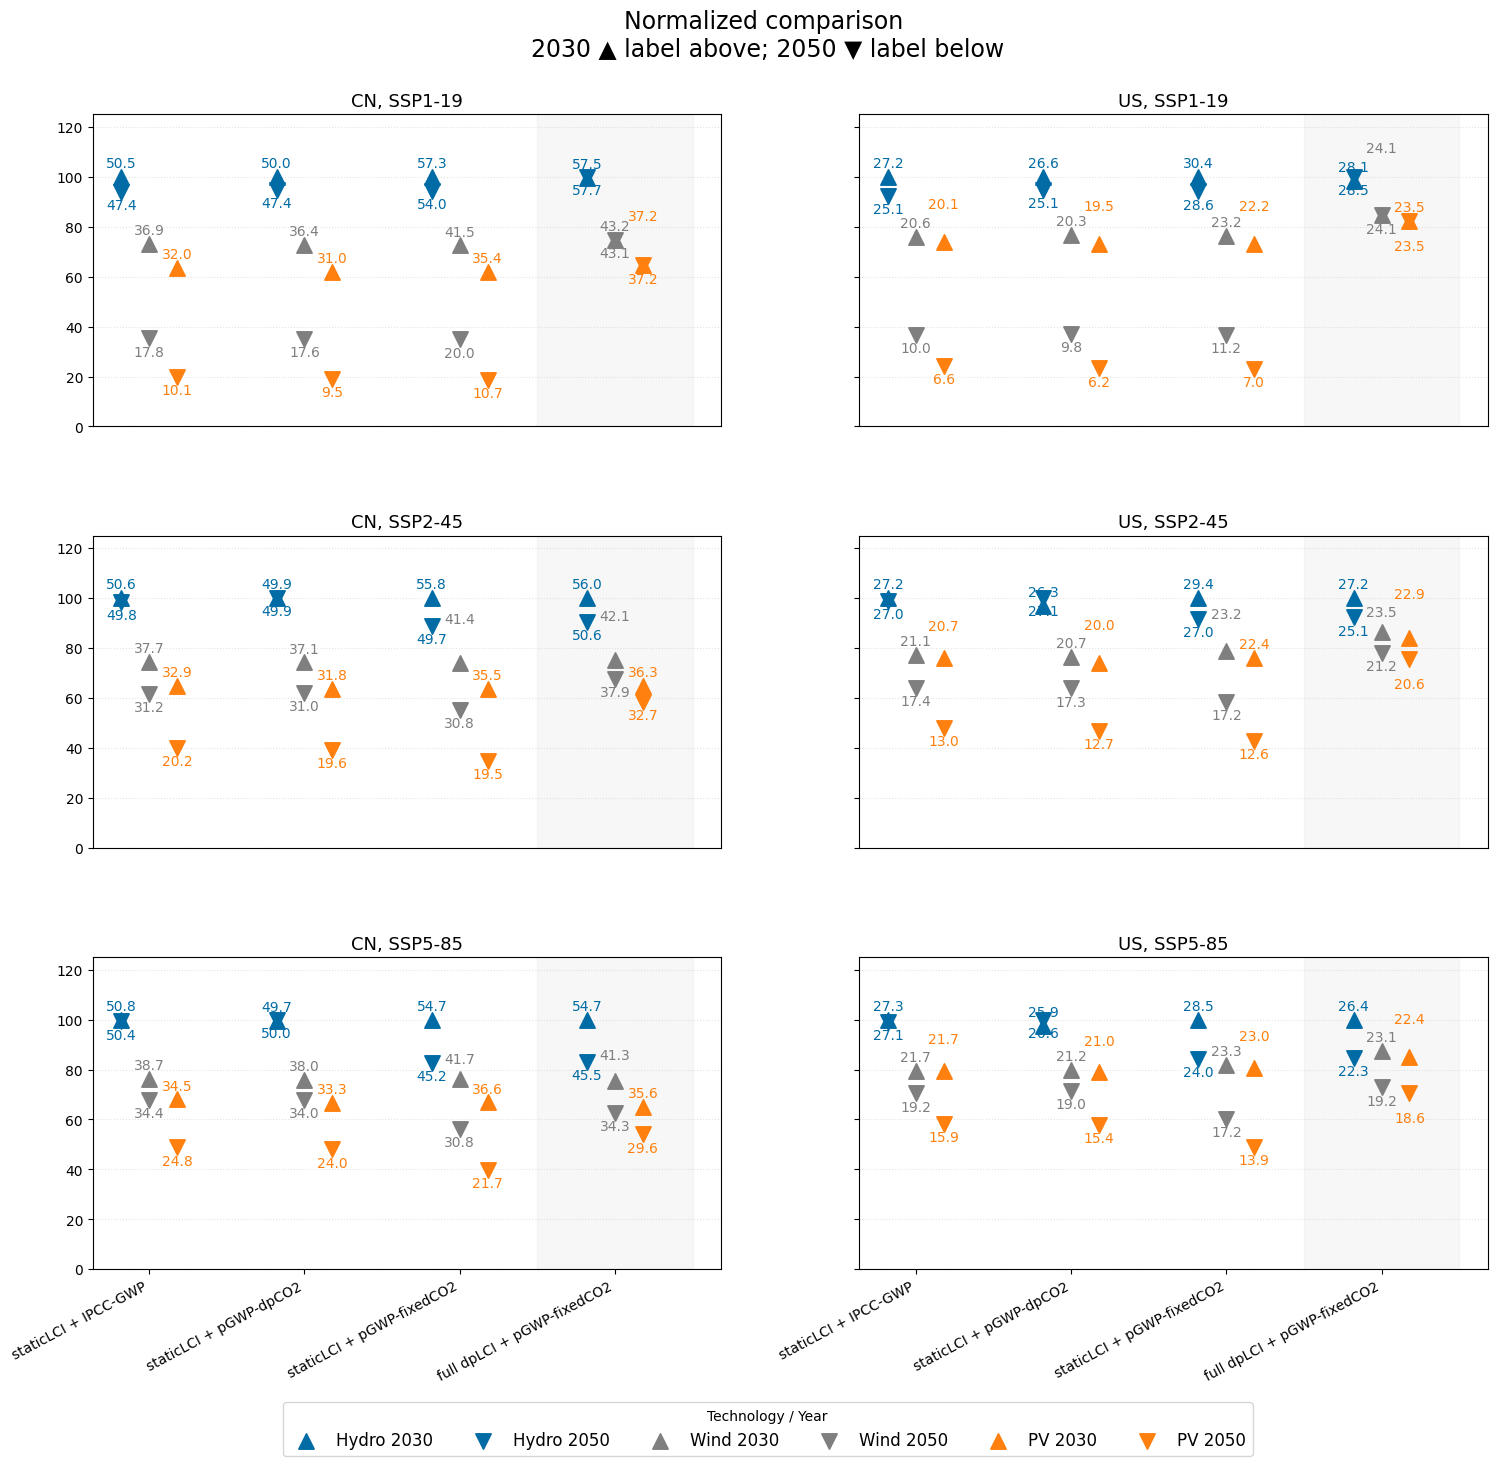

In [10]:
metric_order = [
    "staticLCI + IPCC-GWP",
    "staticLCI + pGWP-dpCO2",
    "staticLCI + pGWP-fixedCO2",
    #"dyn-FG-LCI + pGWP-fixedCO2",
    "full dpLCI + pGWP-fixedCO2",
]

metric_labels = {m: m for m in metric_order}

tech_colors = {"PV":"#FF800E","Wind":"#7F7F7F","Hydro":"#006BA4"}


fig, axes = plot_normalized_dots_replace_bars(
    df_full,
    metric_order=metric_order,
    metric_labels=metric_labels,
    countries=("CN", "US"),
    ssps=("SSP1-VLLO", "SSP2-M", "SSP5-H"),
    technologies=("Hydro", "Wind", "PV"),
    tech_colors=tech_colors,
    norm_choice="both_years",  # "per_year" or "both_years"
    figsize=(18, 15),
)

plt.show()

### old bar plot 

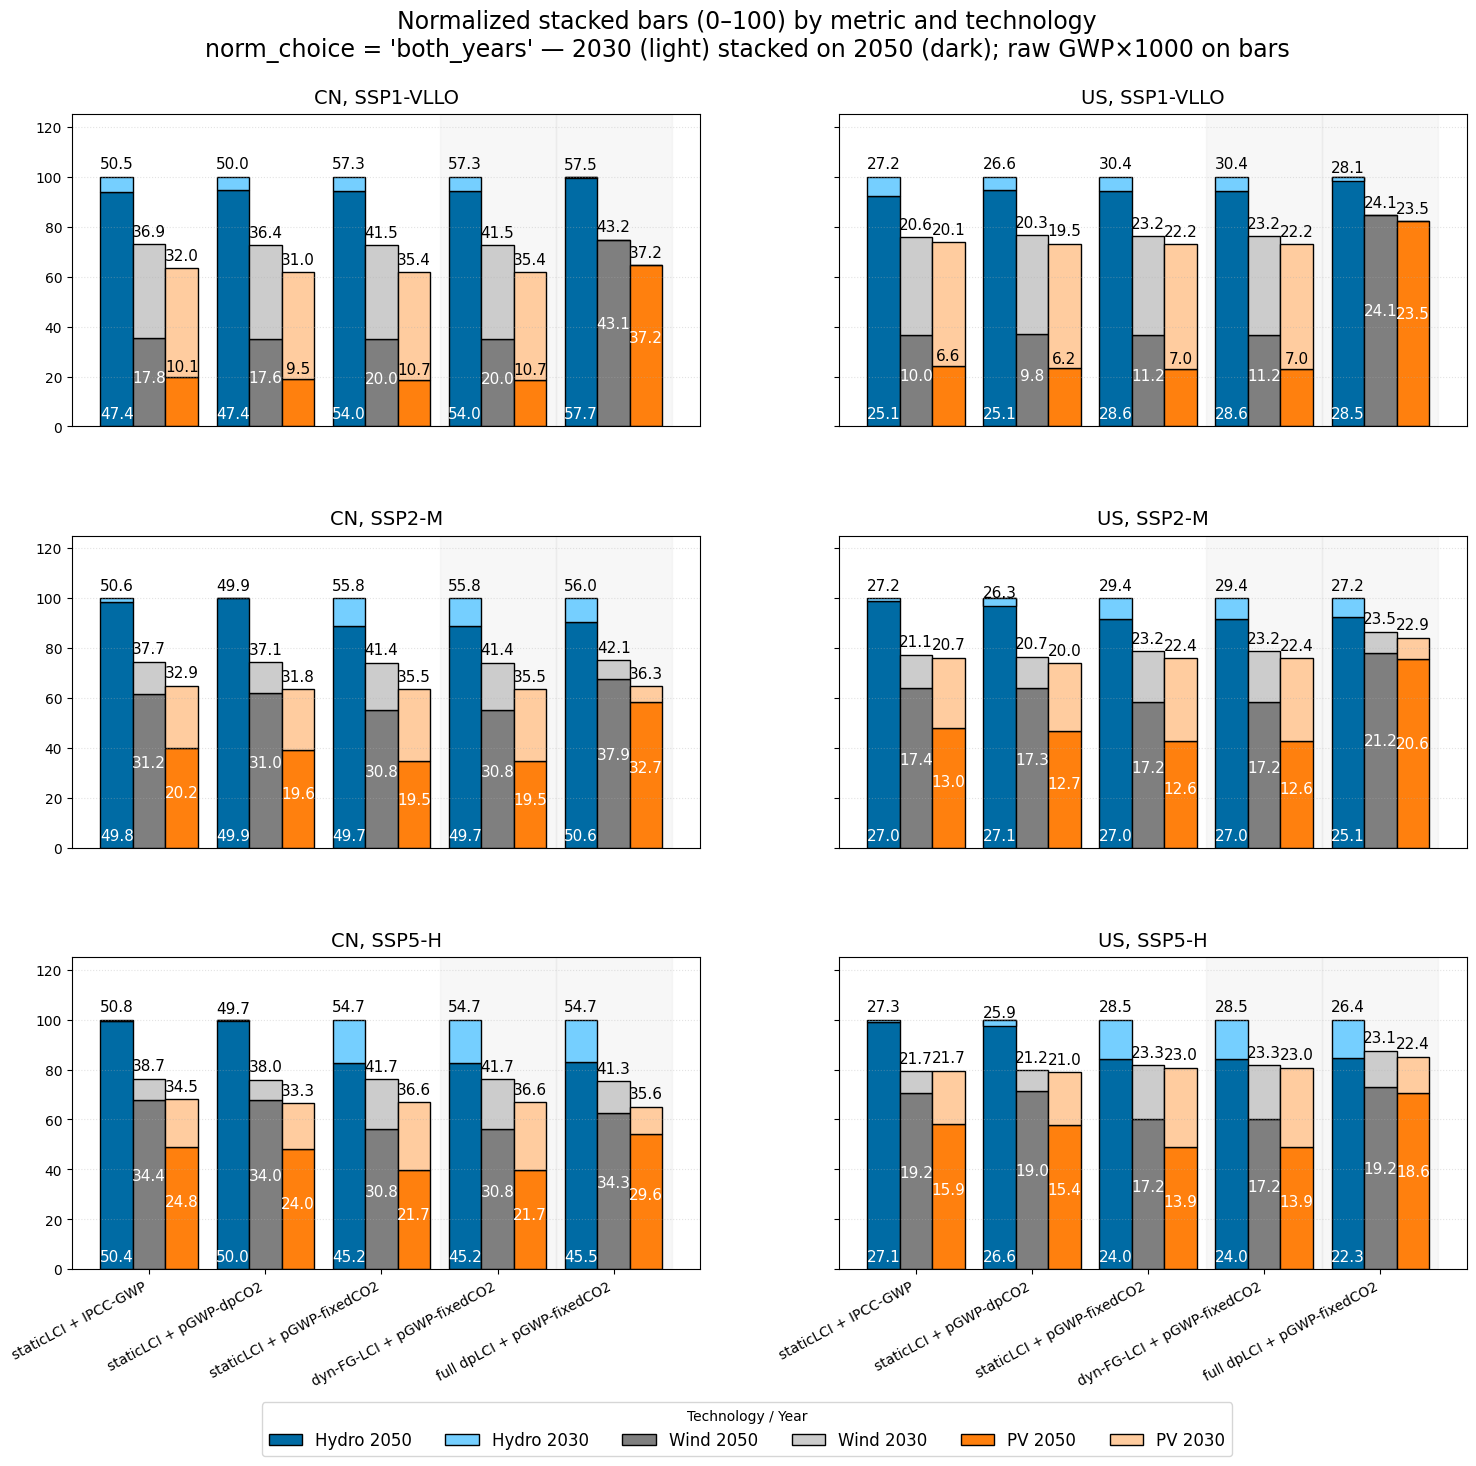

In [5]:
metric_order = [
    "staticLCI + IPCC-GWP",
    "staticLCI + pGWP-dpCO2",
    "staticLCI + pGWP-fixedCO2",
    "dyn-FG-LCI + pGWP-fixedCO2",
    "full dpLCI + pGWP-fixedCO2",
]

metric_labels = {m: m for m in metric_order}

tech_colors = {"PV":"#FF800E","Wind":"#7F7F7F","Hydro":"#006BA4"}

fig, axes = plot_stacked_normalized_bars(
    df_full,
    metric_order=metric_order,
    metric_labels=metric_labels,
    countries=("CN", "US"),
    ssps=("SSP1-VLLO", "SSP2-M", "SSP5-H"),
    technologies=("Hydro", "Wind", "PV"),
    tech_colors=tech_colors,
    bar_width=0.28,
    norm_choice="both_years"  # normalize together for the two years, best for visility cross-year
)

plt.show()


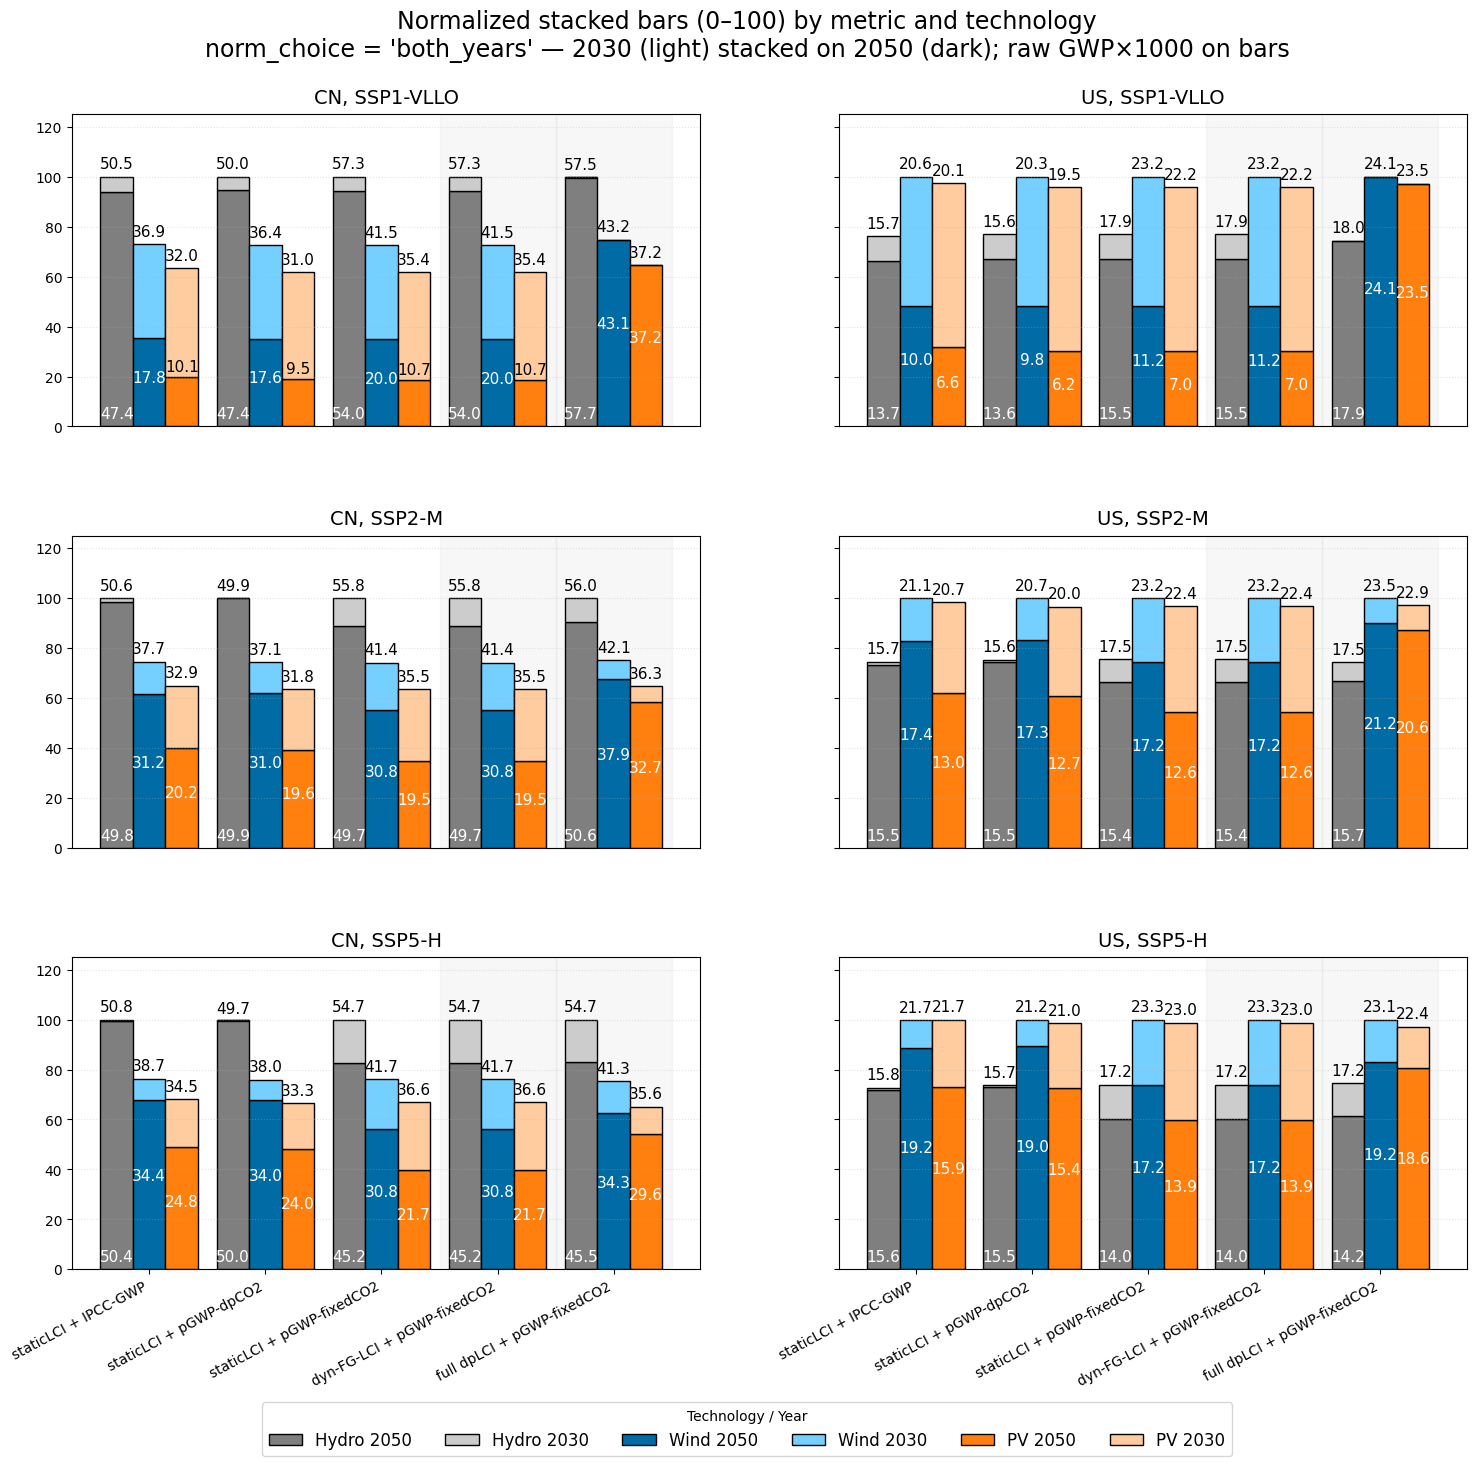

In [12]:
metric_order = [
    "staticLCI + IPCC-GWP",
    "staticLCI + pGWP-dpCO2",
    "staticLCI + pGWP-fixedCO2",
    "dyn-FG-LCI + pGWP-fixedCO2",
    "full dpLCI + pGWP-fixedCO2",
]

metric_labels = {m: m for m in metric_order}

tech_colors = {"PV":"#FF800E","Wind":"#006BA4","Hydro":"#7F7F7F"}

fig, axes = plot_stacked_normalized_bars(
    df_full,
    metric_order=metric_order,
    metric_labels=metric_labels,
    countries=("CN", "US"),
    ssps=("SSP1-VLLO", "SSP2-M", "SSP5-H"),
    technologies=("Hydro", "Wind", "PV"),
    tech_colors=tech_colors,
    bar_width=0.28,
    norm_choice="both_years"  # normalize together for the two years, best for visility cross-year
)

plt.show()

